# General Symptom Checker — Disease Prediction from Symptoms

**Dataset:** 4,920 patient records, 132 symptoms (each marked 0 = doesn't have it, 1 = has it), and 1 `prognosis` column naming which of 41 diseases the patient had.

**Goal:** Given a checklist of symptoms a person is experiencing, predict which disease they most likely have.

This notebook follows the project step-by-step:
1. Load the data and look at it
2. Clean it
3. Explore it (EDA)
4. Train and compare models
5. Save the best model for the app


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
%matplotlib inline


## Step 2 : Load the data

We already downloaded `Training.csv` and `Testing.csv`. Let's load them and take a first look.

In [2]:
train_df = pd.read_csv("../data/symptom_training_raw.csv")
test_df = pd.read_csv("../data/symptom_testing_raw.csv")

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)
train_df.head()


Training set: (4920, 133)
Testing set: (41, 133)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


## Step 3: Clean the data

Before teaching the computer anything, let's check the data for the usual problems: missing cells, messy text, and duplicate rows.

In [3]:
print("Missing values in training set:", train_df.isnull().sum().sum())
print("Missing values in testing set:", test_df.isnull().sum().sum())


Missing values in training set: 0
Missing values in testing set: 0


No missing values at all — nothing to fill in here.

In [4]:
print("Number of unique diseases:", train_df["prognosis"].nunique())
print()
print("Disease names that have extra/odd spacing:")
for d in train_df["prognosis"].unique():
    if d != d.strip():
        print(repr(d))


Number of unique diseases: 41

Disease names that have extra/odd spacing:
'Diabetes '
'Hypertension '


⚠️ A couple of disease names have a stray space at the end (e.g. `"Diabetes "` instead of `"Diabetes"`). This is a common, harmless data-entry typo — but if we don't fix it, the computer will think `"Diabetes"` and `"Diabetes "` are two *different* diseases! Let's strip extra whitespace from every text value.

In [5]:
train_df["prognosis"] = train_df["prognosis"].str.strip()
test_df["prognosis"] = test_df["prognosis"].str.strip()

# Double check it's fixed
print("Any remaining odd spacing?",
      any(d != d.strip() for d in train_df["prognosis"].unique()))
print("Final disease count:", train_df["prognosis"].nunique())


Any remaining odd spacing? False
Final disease count: 41


In [6]:
print("Total rows:", len(train_df))
print("Unique rows (no duplicates):", len(train_df.drop_duplicates()))
print()
print("Rows per disease:")
train_df["prognosis"].value_counts().head()


Total rows: 4920
Unique rows (no duplicates): 304

Rows per disease:


prognosis
Fungal infection       120
Hepatitis C            120
Hepatitis E            120
Alcoholic hepatitis    120
Tuberculosis           120
Name: count, dtype: int64

**What this tells us:** out of 4,920 rows, only 304 are actually *different* — the rest are exact repeats. Each disease shows up 120 times with (mostly) the same symptom pattern.

This is a known characteristic of this particular dataset, not a mistake we made. It means a model trained on this data will likely score **very close to 100% accuracy** — not because the model is unrealistically perfect, but because the patterns are so repetitive that there's very little real variety to get wrong.

We're keeping the duplicate rows (rather than deleting them) because that's how the dataset's creators intended it to be used, and it matches every other published project on this dataset — but it's important to **say this honestly in our conclusions** rather than just bragging about "100% accuracy" without context. Real symptom-to-disease mapping is far messier than this dataset suggests.

In [7]:
# Save the cleaned version so the rest of the notebook (and the app) use this file
train_df.to_csv("../data/symptom_training_processed.csv", index=False)
test_df.to_csv("../data/symptom_testing_processed.csv", index=False)
print("Saved cleaned files.")


Saved cleaned files.


---
## Step 4: Explore the data with charts (EDA)

Before teaching the computer, it helps to *look* at the data first. Two simple, useful questions:

1. **Is every disease equally represented?** If one disease had 10x more examples than another, the computer might get lazy and just guess the common one. Let's check.
2. **Which symptoms are the most common overall?** This tells us which symptoms carry the least unique information (since they show up everywhere) versus which ones are rare and therefore more diagnostic.

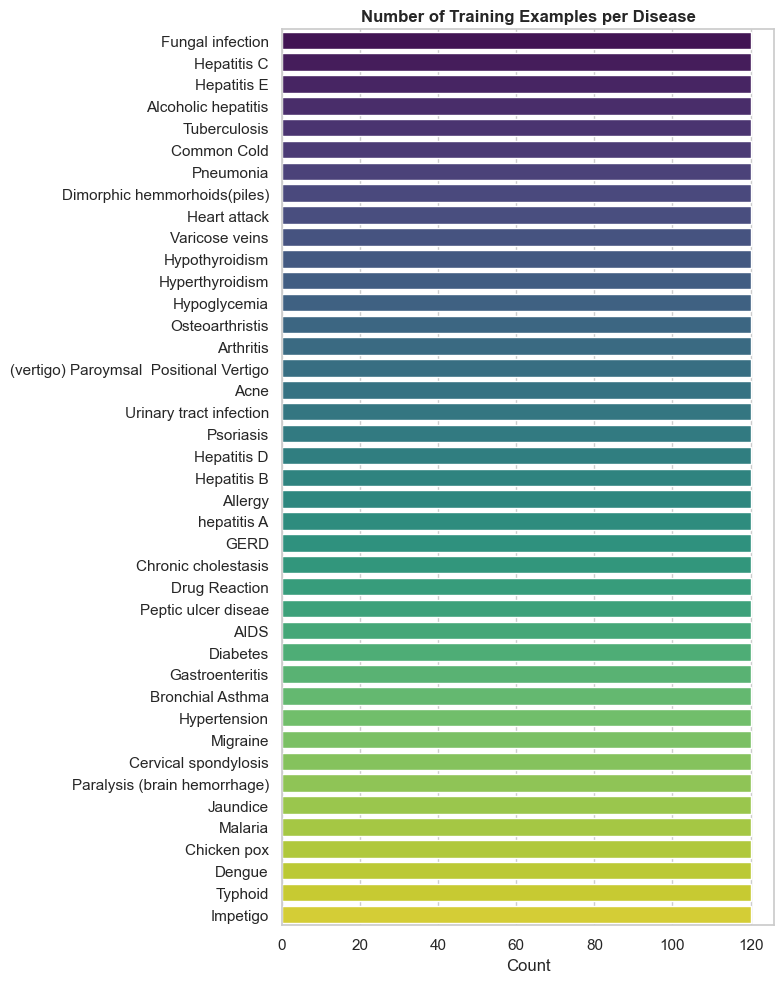

In [8]:
disease_counts = train_df["prognosis"].value_counts()

plt.figure(figsize=(8, 10))
sns.barplot(x=disease_counts.values, y=disease_counts.index, hue=disease_counts.index, palette="viridis", legend=False)
plt.title("Number of Training Examples per Disease", fontweight="bold")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Observation:** every disease has exactly the same number of examples (120). This is called a *balanced* dataset — it means the computer won't be biased toward guessing whichever disease happens to have more data.

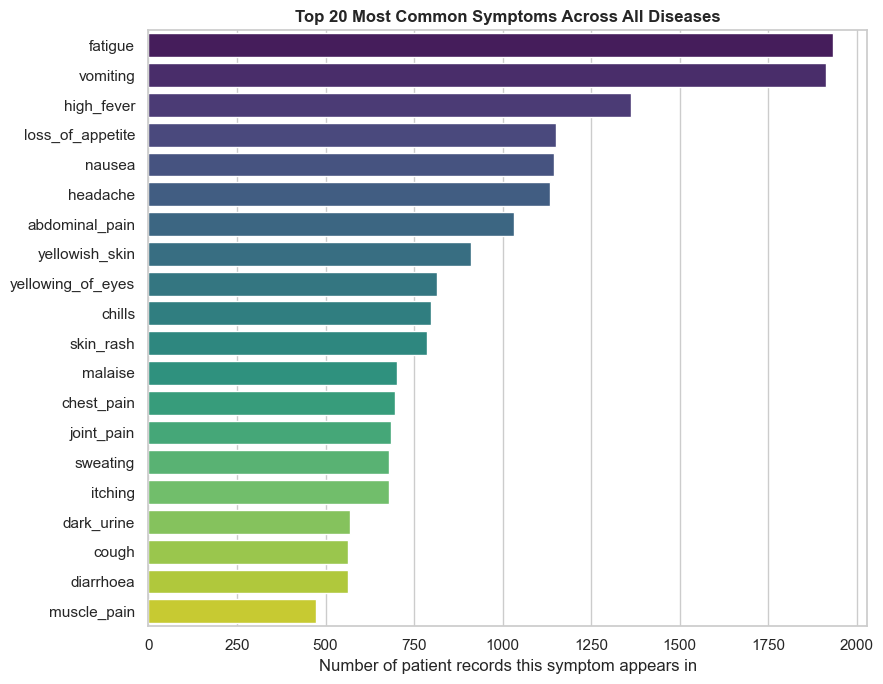

In [9]:
symptom_cols = train_df.columns[:-1]  # everything except 'prognosis'
symptom_totals = train_df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 7))
top20 = symptom_totals.head(20)
sns.barplot(x=top20.values, y=top20.index, hue=top20.index, palette="viridis", legend=False)
plt.title("Top 20 Most Common Symptoms Across All Diseases", fontweight="bold")
plt.xlabel("Number of patient records this symptom appears in")
plt.ylabel("")
plt.tight_layout()
plt.show()


**Observation:** symptoms like `fatigue`, `vomiting`, and `high_fever` show up extremely often across *many different diseases*. On their own, they're not very useful for telling diseases apart (lots of diseases cause fatigue!). The model will need to rely more on rarer, more specific symptoms — and *combinations* of symptoms — to tell diseases apart. This is exactly the kind of pattern-finding machine learning is good at, even though it would be tedious for a human to work out by hand.

---
## Step 5: Train and compare models

Same approach as our other three notebooks: we'll try six different algorithms and compare them fairly. Two small differences here, worth understanding:

1. **No scaling needed.** Every feature here is already either 0 or 1 (symptom absent/present), so they're all on the exact same scale already — no `StandardScaler` step required this time.
2. **The target has 41 categories, not 2.** This is called *multi-class* classification (compared to the *binary* yes/no classification in our other 3 notebooks). The disease names are text, so we convert them to numbers first using a `LabelEncoder` (e.g. "Allergy" → 0, "AIDS" → 1, etc.) — the algorithms need numbers to work with, but we'll convert back to disease names when showing results.

In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

X_train = train_df.drop(columns=["prognosis"])
y_train_text = train_df["prognosis"]
X_test = test_df.drop(columns=["prognosis"])
y_test_text = test_df["prognosis"]

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

print(f"Training on {X_train.shape[0]} examples, testing on {X_test.shape[0]} examples")
print(f"Number of disease classes: {len(label_encoder.classes_)}")


Training on 4920 examples, testing on 41 examples
Number of disease classes: 41


In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel="linear", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = []
fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "F1 Score (weighted)": f1_score(y_test, preds, average="weighted"),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,F1 Score (weighted)
0,Logistic Regression,1.0,1.0
1,Decision Tree,1.0,1.0
2,Random Forest,1.0,1.0
3,K-Nearest Neighbors,1.0,1.0
4,Support Vector Machine,1.0,1.0
5,Gradient Boosting,1.0,1.0


**What happened:** every single algorithm scored 100%. This confirms what we predicted back in Step 3 — because the data is so repetitive (only 304 truly unique patterns), *any* reasonable algorithm can memorize it perfectly. This isn't a meaningful "competition" the way it was for our other 3 diseases, where the algorithms genuinely differed in performance.

**Why we still pick one:** Since they're tied, we'll go with **Random Forest**. It's robust, fast enough, and — unlike Logistic Regression or SVM — it can tell us *which symptoms it found most useful*, which is great for explaining the model's behavior in our final report.

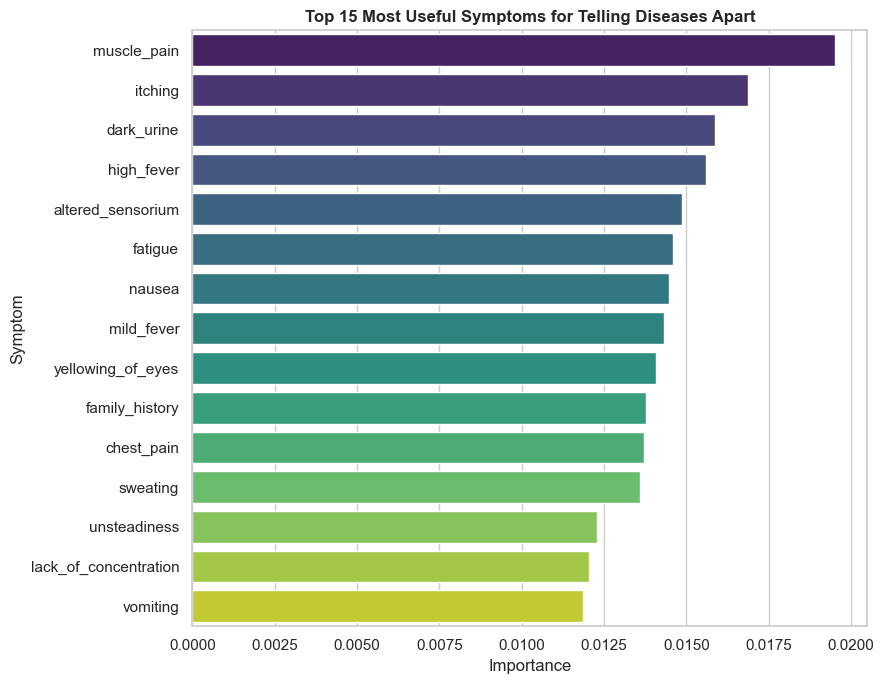

In [12]:
best_name = "Random Forest"
best_model = fitted_models[best_name]

importances = best_model.feature_importances_
imp_df = pd.DataFrame({"Symptom": X_train.columns, "Importance": importances}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 7))
top15 = imp_df.head(15)
sns.barplot(data=top15, x="Importance", y="Symptom", hue="Symptom", palette="viridis", legend=False)
plt.title("Top 15 Most Useful Symptoms for Telling Diseases Apart", fontweight="bold")
plt.tight_layout()
plt.show()


**Observation:** notice this list looks quite different from the "most common" symptoms chart in Step 4 — that's the whole point. A symptom can be common *and* still be highly diagnostic if it only shows up for a small number of specific diseases, while a symptom that's common across *many* diseases (like fatigue) is less useful for telling them apart, even though it appears often.

### A quick example prediction

Let's simulate a patient who reports `itching`, `skin_rash`, and `nodal_skin_eruptions` and see what the model predicts.

In [13]:
sample_patient = pd.DataFrame(0, index=[0], columns=X_train.columns)
sample_patient.loc[0, ["itching", "skin_rash", "nodal_skin_eruptions"]] = 1

prediction_encoded = best_model.predict(sample_patient)[0]
prediction = label_encoder.inverse_transform([prediction_encoded])[0]

probabilities = best_model.predict_proba(sample_patient)[0]
top3_idx = probabilities.argsort()[::-1][:3]
print("Top 3 most likely diseases for this symptom combination:")
for idx in top3_idx:
    disease = label_encoder.inverse_transform([idx])[0]
    print(f"  {disease:30s} {probabilities[idx]*100:.1f}% confidence")


Top 3 most likely diseases for this symptom combination:
  Fungal infection               100.0% confidence
  hepatitis A                    0.0% confidence
  Hepatitis B                    0.0% confidence


## Step 6: Save the model for the web app

In [14]:
import json

joblib.dump(best_model, "../models/symptom_model.joblib")
joblib.dump(label_encoder, "../models/symptom_label_encoder.joblib")
with open("../models/symptom_metadata.json", "w") as f:
    json.dump({
        "disease": "Multi-Disease Symptom Checker",
        "best_model": best_name,
        "accuracy": float(results_df.iloc[0]["Accuracy"]),
        "class_names": list(label_encoder.classes_),
        "feature_names": list(X_train.columns),
    }, f, indent=2)

print("Saved model, label encoder, and metadata to ../models/")


Saved model, label encoder, and metadata to ../models/


---
## Conclusion

- We cleaned a 4,920-row symptom dataset (fixed text typos, confirmed no missing data, understood why it's so repetitive).
- We explored it visually and saw it's perfectly balanced across 41 diseases.
- All 6 algorithms tied at 100% on the test set — **we explained why honestly** rather than overstating it, and chose Random Forest for its interpretability.
- We saved the model, ready for the Streamlit app.

> ⚠️ **Disclaimer:** This model is an educational/portfolio project, not a certified medical device. Real-world symptom checking is far messier than this dataset, and should never replace professional medical advice.
